# Change github.com to githubtocolab.com to open colab 

In [ ]:
import os
import sys

!git clone https://github.com/cegranger/craps-ai.git

os.chdir("craps-ai")
sys.path.append(os.getcwd())
# raise RuntimeError(sys.path) # Debug module not found.


!git checkout notebook-opencv  
!pip install -r requirements.txt &> /dev/null


# Génération d'un ensemble de données pour entrainer ton IA

In [ ]:
from dice_detection import run_dice_detection
run_dice_detection()

# Est-ce que c'est bien ça ? 

2025-09-29 10:37:12.608268: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-29 10:37:12.608489: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-29 10:37:12.641702: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-29 10:37:13.672187: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Found 272 files belonging to 6 classes.
Using 218 files for training.
Using 54 files for validation.


2025-09-29 10:37:14.194523: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


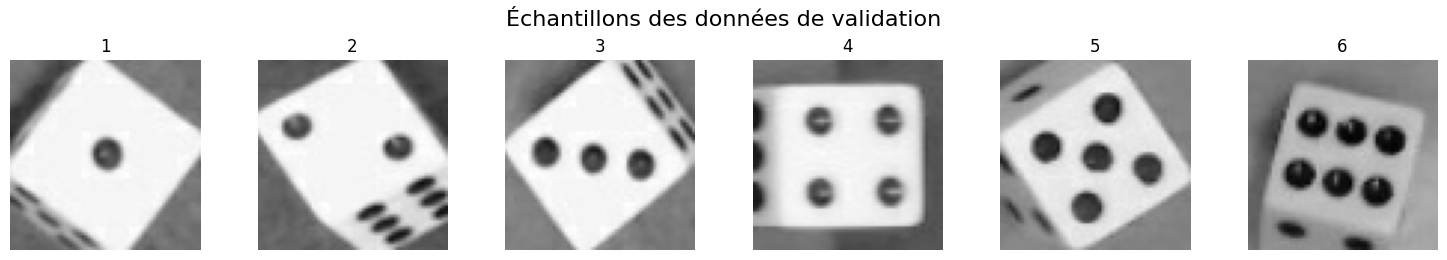

None


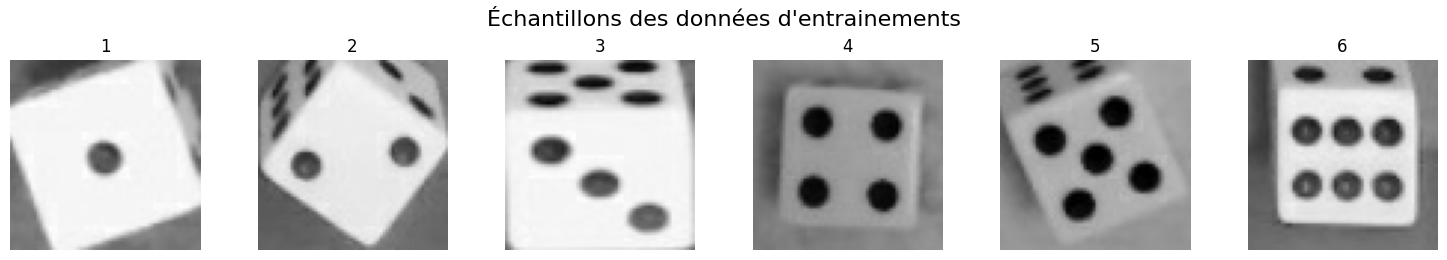

None


In [ ]:
import matplotlib.pyplot as plt
from datasets.dataset import Dataset

# affiche les données de validation 0 et d'entrainement 1
data = Dataset()
data.plot_classes(0) 
data.plot_classes(1)


# Example de convolution ? 

In [2]:
import pandas as pd
import numpy as np
from PIL import Image

img = Image.open('datasets/opencv_dataset/1/20250212-143518.jpg')
# Convert to grayscale if it's a color image
if img.mode != 'L':
    img = img.convert('L')

# Resize to 15x15
img_resized = img.resize((16, 16), Image.BILINEAR)

img_array = np.array(img_resized)

# Display as DataFrame with styling
df = pd.DataFrame(img_array.astype(int))
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,108,84,73,117,209,238,215,170,130,114,116,116,115,116,117,121
1,97,85,124,186,239,246,246,241,222,185,148,120,109,115,119,121
2,88,122,173,214,245,246,246,246,246,244,235,210,167,141,128,119
3,82,122,183,231,246,246,246,246,246,246,246,246,242,228,196,151
4,90,137,199,242,246,246,246,246,246,246,246,246,246,246,245,234
5,122,150,218,245,246,246,246,246,245,246,247,246,246,246,246,237
6,123,160,235,246,246,246,244,204,162,216,245,246,246,246,246,204
7,127,188,244,246,246,246,235,112,53,123,237,246,246,246,239,162
8,126,201,246,246,246,246,237,125,60,125,237,246,246,246,220,130
9,127,229,246,246,246,246,245,212,167,212,245,246,246,244,185,114


# Crée un réseau de neurone convolutionnel ! 

/home/grac2310/ti-herbe/craps-ai/git/craps-ai/.venv/lib64/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/grac2310/ti-herbe/craps-ai/git/craps-ai/.venv/lib64/python3.10/site-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


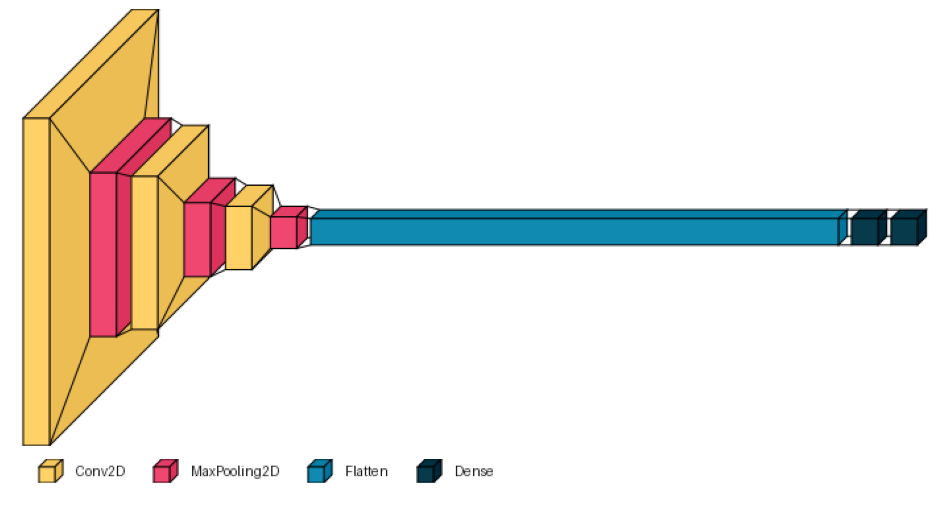

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=data.input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')  # Output layer for 6 classes
])

# model.summary()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Generate the model plot
import visualkeras
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import numpy as np

# Method 1: Display inline using matplotlib
fig = visualkeras.layered_view(model, legend=True, font_color='black')
plt.figure(figsize=(12, 8))
plt.imshow(np.array(fig))
plt.axis('off')
plt.show()


# Entraine le CNN! 

In [4]:
# Check what your dataset contains
for images, labels in data.train_data.take(1):
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels values: {labels[:5]}")  # Show first 5 labels

Images shape: (32, 64, 64, 3)
Labels shape: (32, 6)
Labels values: [[0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0.]]


2025-09-29 10:37:48.502323: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
# Train the model
epochs = 10
history = model.fit(
    data.train_data,
    validation_data=data.val_data,
    epochs=epochs
)

# Evaluate the model
loss, accuracy = model.evaluate(data.val_data)
print(f"Précision sur données de validations: {accuracy * 100:.2f}%")

# Save model
model.save('models/craps-ai/opencv_cnn.h5')

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 1.8401e-04 - val_accuracy: 0.9259 - val_loss: 0.4924
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 1.6998e-04 - val_accuracy: 0.9259 - val_loss: 0.4951
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 1.5563e-04 - val_accuracy: 0.9259 - val_loss: 0.4985
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 1.4532e-04 - val_accuracy: 0.9259 - val_loss: 0.5002
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 1.3579e-04 - val_accuracy: 0.9259 - val_loss: 0.5007
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 1.2844e-04 - val_accuracy: 0.9259 - val_loss: 0.5039
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 1.2069e-04 - val_accuracy: 0.9259 - val_loss: 0.5065
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 1.1315e-04 - val_accu

Précision sur données de validations: 92.59%


# Joue au Craps avec ton CNN !

In [1]:

import queue
from craps_game_controller import CrapsGameController, ThreadSafeFrameBuffer

# Create shared resources
event_queue = queue.Queue()
frame_buffer = ThreadSafeFrameBuffer()

# Create and display the control panel
controller = CrapsGameController(event_queue, frame_buffer)
display(controller.display())

pygame 2.6.1 (SDL 2.28.4, Python 3.10.18)
Hello from the pygame community. https://www.pygame.org/contribute.html


/home/grac2310/ti-herbe/craps-ai/git/craps-ai/.venv/lib64/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Game thread: Mode set to manual
Game thread: Mode set to cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thread: rolling with cnn
Game thre